---
format:
    html:
        embed-resources: true
---

# Lab: Linear Discriminant Analysis (LDA) and Quadratic Discriminant Analysis (QDA) in Python

Author: Dr. H and Gertrude Tiberius Parker the 5th

**Goal.** Implement, train, and evaluate **LDA** and **QDA** classifiers on a standard “textbook” dataset, then interpret results in terms of the underlying modeling assumptions (shared vs class-specific covariance).

**Dataset.** Use the **Breast Cancer Wisconsin (Diagnostic)** dataset from `sklearn.datasets`.

* Binary classification (malignant vs benign)
* Numeric features only (good fit for LDA/QDA assumptions)

* Provide clean, reproducible code, incorporate helper functions where relevant.

**Deliverables.**

Submit a rendered version of this notebook (HTML or PDF) to Canvas, make sure all code cells have been run and images are visible in the uploaded document. 

**Demonstration:**

Use ISLP Chapter-4 lab notebook examples for reference and demonstration. 


## Demonstration

Use ISLP Chapter-4 lab notebook examples for reference and demonstration. 


# Assignment


## Sub-assignment-1: Setup and dataset ingestion

1. Import required packages.
2. Load the dataset from `sklearn.datasets`.
3. Create `X` (features) and `y` (labels).
4. Print:

   * `X.shape`, `y.shape`
   * Class counts
   * Feature names (first 10 is fine)

**Expected output artifacts:** small summary printout.

In [153]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd

# load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns = data['feature_names']) # features
y = pd.Series(data.target, name = 'target') # labels

print('X shape:', X.shape) # X shape
print('y shape:', y.shape) # y shape
print('count class:', len(np.unique(y))) # class counts
print('first 10 feature names: ', data['feature_names'][:10])


X shape: (569, 30)
y shape: (569,)
count class: 2
first 10 feature names:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension']




## Sub-assignment-2: Train/validation/test split

1. Split the dataset into:

   * **Train:** 60%
   * **Validation:** 20%
   * **Test:** 20%
2. Use **stratified splits** so class balance is preserved.
3. Report class balance for each split.

**Hint:** Use `train_test_split(..., stratify=y)` twice.


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
  X, y,
  test_size=0.4,
  random_state=42,
  shuffle=True,
  stratify = y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,     # split temp to val and test
    random_state=42,
    stratify=y_temp
)

## Sub-assignment-3: Build a reusable classification report utility function

To ensure **consistent and fair evaluation** across all classifiers in this lab, you will implement a reusable utility that computes standard classification metrics and generates the key diagnostic plots. You will use this same function for the baseline model, LDA, and QDA.

The function should work for **any number of classes** and for any of the dataset splits (train/validation/test).

1. Create a helper function named `classification_report`.

2. The function must accept:
   * The true class labels
   * The predicted class labels
   * Optionally, predicted class probabilities or decision scores (used for threshold/ROC-style plots when available)
   * (Recommended) an optional `title` or `split_name` string so printed output/plots are labeled clearly

3. The function must compute and **print** (not return) the following:
   * Overall accuracy
   * Per-class precision, recall, and F1-score
   * Macro-averaged F1-score
   * Confusion matrix (as both a printed matrix and a plotted heatmap)

4. The function must also generate the following plots:
   * Confusion matrix heatmap (with class names on axes)
   * If probabilistic scores are provided:
     * ROC curve (binary) or one-vs-rest ROC curves (multiclass), with AUC values shown

5. The function must:
   * **Not return anything** (i.e., it prints results and makes plots only)
   * Produce a clean, readable summary with clearly labeled metrics and plots
   * Handle multiclass settings gracefully (e.g., by computing per-class metrics automatically)

6. Verify correctness by testing the function on a small, manually defined example with known labels and predictions (and scores if you want to test ROC behavior).

7. Use this utility for **all model evaluations** in the remainder of the lab:
   * Baseline classifier
   * LDA
   * QDA

This sub-assignment is required so that all models are evaluated using **identical metrics and visual diagnostics**, enabling a meaningful apples-to-apples comparison.


In [155]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc



def classification_report(x_train, y_train, x_val, y_val, model):
  # Call the model
  out = model(x_train, y_train, x_val)

  # Check if model_func returns y_prob
  if len(out) == 2:
      y_pred, y_prob = out
  else:
      y_pred = out
      y_prob = None  # Not available

  # overall accuracy
  accuracy = accuracy_score(y_val, y_pred)
  # precison, recal, f1
  precision, recall, f1, support = precision_recall_fscore_support(
    y_val,
    y_pred,
    labels=[0, 1]
  )
  # macro average f1 score
  macro_avg_f1 = (f1[0] + f1[1])/2

  # create dataframe for evaluation scores
  metrics_df = pd.DataFrame({
    'precision': precision,
    'recall': recall,
    'F1-score': f1
  }, index=['class_0', 'class_1'])

  # confusion matrix
  cm = confusion_matrix(y_val, y_pred, labels=[0,1])
  cm_df = pd.DataFrame(
    cm,
    index = ['actual0','actual1'],
    columns = ['pred_0', 'pred_1']
  )

  # print accuracy metrics
  print('Overall accuracy:', accuracy)
  print('\n')
  print(metrics_df)
  print('\n')
  print('Macro Averaged F1:', macro_avg_f1)
  print('\n')
  print('Confusion matrix:\n', cm_df)

  # plot confusion matrix heatmap
  plt.figure(figsize=(5,4))
  sns.heatmap(cm, annot=True, cmap='coolwarm')
  plt.title('Confusion matrix plot')
  plt.xlabel('Predicted Class')
  plt.ylabel('Actual Class')
  plt.show()

  if len(out) == 2:
  # plot ROC curve
    y_prob_pos = y_prob[:, 1]
    fpr, tpr, thresholds = roc_curve(y_val, y_prob_pos)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
  else:
    pass

## Sub-assignment-4: Baseline model

1. Train a baseline classifier: **Logistic Regression**.
2. Standardize features using `StandardScaler` (fit on train only; transform val/test).
3. Evaluate on validation set:
   * Accuracy
   * Confusion matrix
   * Precision, recall, F1


In [156]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

Overall accuracy: 0.956140350877193


         precision    recall  F1-score
class_0   0.974359  0.904762  0.938272
class_1   0.946667  0.986111  0.965986


Macro Averaged F1: 0.9521289997480473


Confusion matrix:
          pred_0  pred_1
actual0      38       4
actual1       1      71


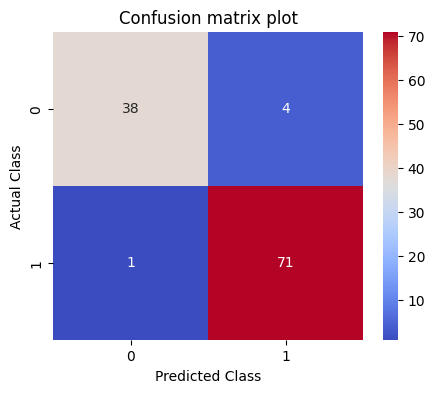

In [157]:
from sklearn.linear_model import LogisticRegression

# baseline logistic regression model
def logistic_model(x_train, y_train, x_val):
  model = LogisticRegression()
  model.fit(x_train, y_train) # fit model with training data
  y_pred = model.predict(x_val) # predict y class labels
#  y_prob = model.predict_proba(x_val) # Predict probabilities
  return y_pred

# display classfication report
classification_report(X_train, y_train, X_val, y_val, logistic_model)


## Sub-assignment-5: LDA model training and evaluation
1. Train an LDA classifier.

2. Use the same preprocessing approach as baseline:
* Standardize features with StandardScaler inside a Pipeline.
3. Evaluate on validation set:
* Accuracy
* Confusion matrix
* Precision, recall, F1
* Compare LDA metrics to the baseline in a small table.

**Written response (short)**: Explain why LDA might perform similarly to logistic regression on some datasets.

Overall accuracy: 0.9473684210526315


         precision    recall  F1-score
class_0   0.973684  0.880952  0.925000
class_1   0.934211  0.986111  0.959459


Macro Averaged F1: 0.9422297297297297


Confusion matrix:
          pred_0  pred_1
actual0      37       5
actual1       1      71


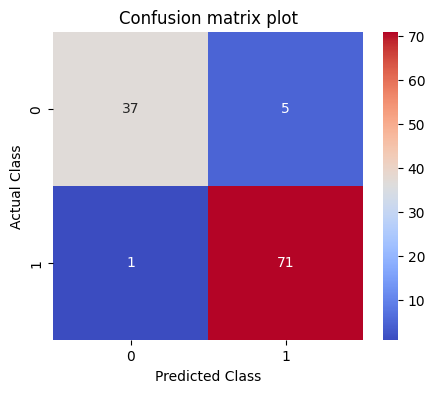

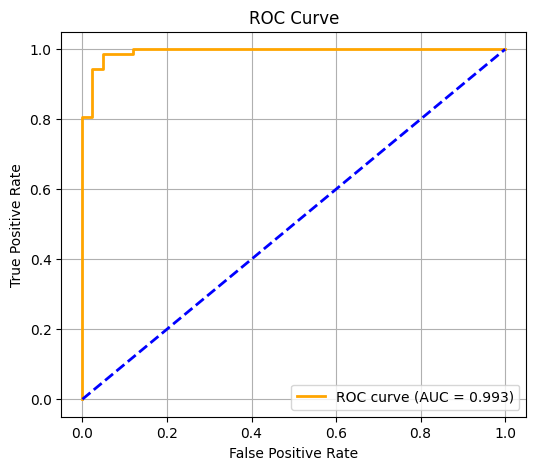

In [158]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# define LDA model
def lda_model(x_train, y_train, x_val):
  scaler = StandardScaler()

  # standardize x_train and x_val
  x_train_s = scaler.fit_transform(x_train) # standardize x_train
  x_val_s = scaler.fit_transform(x_val) # standardize x_val

  # train LDA
  model = LinearDiscriminantAnalysis()
  model.fit(x_train_s, y_train)

  # prediction
  y_pred = model.predict(x_val_s)
  y_prob = model.predict_proba(x_val_s)

  return y_pred, y_prob


# display classification report
classification_report(X_train, y_train, X_val, y_val, lda_model)



## Sub-assignment-6: QDA model training and evaluation

1. Train a **QDA** classifier.
2. Use the same `Pipeline` approach (scaler + QDA).
3. Evaluate on validation set (same metrics as above).
4. Compare QDA vs LDA vs baseline on the validation set.

**Written response (short):**
Explain what extra flexibility QDA has compared to LDA, and what the tradeoff is.


Overall accuracy: 0.9385964912280702


         precision    recall  F1-score
class_0   0.948718  0.880952  0.913580
class_1   0.933333  0.972222  0.952381


Macro Averaged F1: 0.9329805996472662


Confusion matrix:
          pred_0  pred_1
actual0      37       5
actual1       2      70


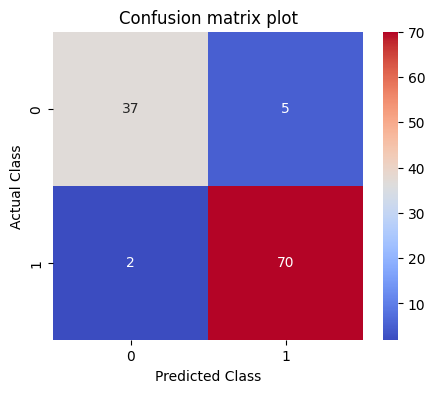

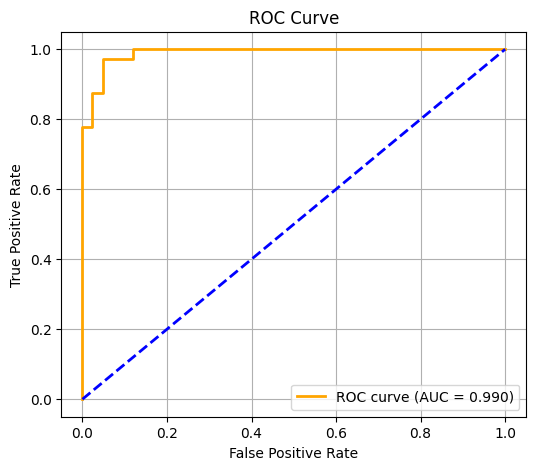

In [159]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# define QDA model
def qda_model(x_train, y_train, x_val):
  scaler = StandardScaler()

  # standardize x_train and x_val
  x_train_s = scaler.fit_transform(x_train) # standardize x_train
  x_val_s = scaler.fit_transform(x_val) # standardize x_val

  # train QDA
  model = QuadraticDiscriminantAnalysis()
  model.fit(x_train_s, y_train)

  # prediction
  y_pred = model.predict(x_val_s)
  y_prob = model.predict_proba(x_val_s)

  return y_pred, y_prob

# display classification report
classification_report(X_train, y_train, X_val, y_val, qda_model)


##### **1. Compare LDA & QDA vs. Baseline model:**
Comparing LDA and QDA with the baseline model, LDA and QDA both have worse accuracy scores including F1 scores than the baseline model, for both class0 and class1 predictions. 
QDA has better performance than LDA on predicting class0; LDA has better performance on predicting class1. 

##### **2. Extra flexibility QDA has compared to LDA, and the tradeoff is**
* LDA assumes all classes have the same covariance. QDA allows classes to have different covariance. Alos, QDA model on each class.
* QDA requires more data in each class to train the model. More vulnerable to the noise in small dataset and risk overfit. Higher variance. More calculations and more parameters generated.



## Sub-assignment-7: Hyperparameter exploration (regularization)

QDA can be numerically unstable when covariance estimates are ill-conditioned.

1. For **QDA**, sweep `reg_param` over a small grid, e.g.
   `reg_param ∈ {0.0, 0.01, 0.05, 0.1, 0.2}`
2. For each value, record validation metrics.
3. Choose the best `reg_param` based on **validation F1** (or accuracy, but state your choice).

**Deliverable:** a small table + a simple line plot of metric vs `reg_param`.


In [160]:
import warnings
from scipy.linalg import LinAlgWarning

warnings.filterwarnings("ignore", category=LinAlgWarning)

,reg_param,F1
0,0.00,0.932981
1,0.01,0.961911
2,0.05,0.962302
3,0.10,0.971863
4,0.20,0.971863
5,0.50,0.971583


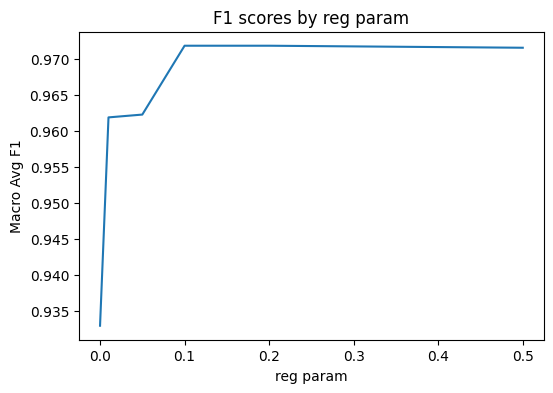

In [161]:
reg_param = [0, 0.01, 0.05, 0.1, 0.2, 0.5]

# define QDA reg_param model
def qda_regparam_model(x_train, y_train, x_val):
  scaler = StandardScaler()

  # standardize x_train and x_val
  x_train_s = scaler.fit_transform(x_train) # standardize x_train
  x_val_s = scaler.fit_transform(x_val) # standardize x_val

  result = []
  # train QDA
  for reg in reg_param:
      model = QuadraticDiscriminantAnalysis(reg_param=reg)
      model.fit(x_train_s, y_train)

      # prediction
      y_pred = model.predict(x_val_s)

      # Metrics
      precision, recall, f1, _ = precision_recall_fscore_support(
            y_val, y_pred, average=None
        )
      macro_f1 = f1.mean()
      result.append({
          'reg_param': reg,
          'F1': macro_f1
      })
  result = pd.DataFrame(result)

  return result

# print the result table
qda_regparam_model(X_train, y_train, X_val)
result_table = qda_regparam_model(X_train, y_train, X_val)
display(result_table)

# plot the result
plt.figure(figsize=(6,4))
plt.plot(result_table['reg_param'],
         result_table['F1'])
plt.xlabel('reg param')
plt.ylabel('Macro Avg F1')
plt.title('F1 scores by reg param')
plt.show()



## Sub-assignment-8: Visualization in 2D via PCA

Since the dataset is high-dimensional, reduce to 2D for visualization.

1. Fit **PCA(n_components=2)** on the training set only.
2. Transform train/val/test into 2D.
3. Train **LDA** and **QDA** in this 2D space (no need to scale if you PCA after scaling; just be consistent).
4. Plot:

   * Scatter plot of validation points in PCA space colored by class
   * Decision boundary overlay for LDA
   * Decision boundary overlay for QDA (separate plot or same plot with clear labeling)



In [162]:
from sklearn.decomposition import PCA

# define LDA PCA model
def pda(x_train, x_val):
  scaler = StandardScaler()

  # standardize x_train and x_val
  x_train_s = scaler.fit_transform(x_train) # standardize x_train
  x_val_s = scaler.fit_transform(x_val) # standardize x_val

  # PCA transform x_train and x_val
  pca = PCA(n_components=2)
  x_train_pca = pca.fit_transform(x_train_s)
  x_val_pca = pca.fit_transform(x_val_s)

  return x_train_pca, x_val_pca


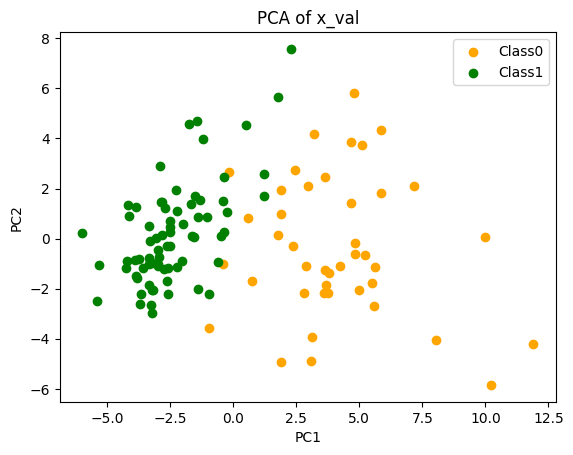

In [163]:
# scatter plot of the pca of val

# x_val pca
x_val_pca = pda(X_train, X_val)[1]
x_val_class0_pc1 = x_val_pca[y_val ==0, 0] # pc1 of class0
x_val_class0_pc2 = x_val_pca[y_val ==0, 1] # pc2 of calss0
x_val_class1_pc1 = x_val_pca[y_val ==1, 0] # pc1 of class1
x_val_class1_pc2 = x_val_pca[y_val ==1, 1] # pc2 of calss1

# plot
plt.scatter(
  x_val_class0_pc1,
  x_val_class0_pc2,
  color='orange',
  label = 'Class0'
)

plt.scatter(
  x_val_class1_pc1,
  x_val_class1_pc2,
  color='green',
  label = 'Class1'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of x_val')
plt.legend()

In [164]:
# define LDA model
def lda_pca_model(x_train_pca, y_train, x_val_pca):

  # train LDA
  model = LinearDiscriminantAnalysis()
  model.fit(x_train_pca, y_train)

  # prediction
  y_pred = model.predict(x_val_pca)
  y_prob = model.predict_proba(x_val_pca)

  return y_pred, y_prob


In [165]:
# x_train in PCA 2D space
x_train_pca = pda(X_train, X_val)[0]
# x_val in PCA 2D space
x_val_pca = pda(X_train, X_val)[1]

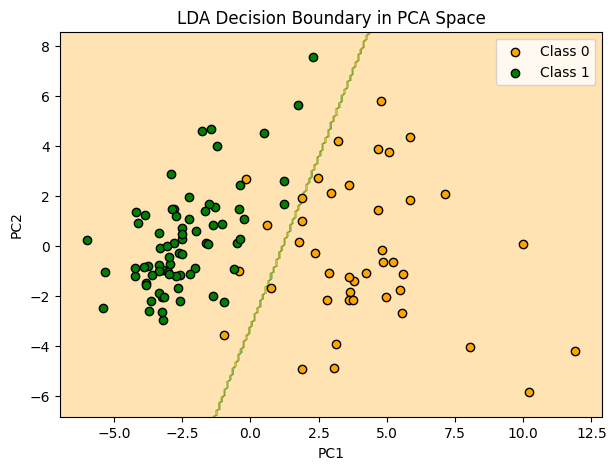

In [166]:
# decision overlay for LDA

# create mesh grid
x_min, x_max = x_val_pca[:, 0].min() - 1, x_val_pca[:, 0].max() + 1
y_min, y_max = x_val_pca[:, 1].min() - 1, x_val_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# predict for each point in the grid
lda = LinearDiscriminantAnalysis()
lda.fit(x_train_pca, y_train)
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, colors=['orange','green'])

# plot validation points
plt.scatter(x_val_pca[y_val==0,0], x_val_pca[y_val==0,1], color='orange', label='Class 0', edgecolor='k')
plt.scatter(x_val_pca[y_val==1,0], x_val_pca[y_val==1,1], color='green', label='Class 1', edgecolor='k')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('LDA Decision Boundary in PCA Space')
plt.legend()
plt.show()


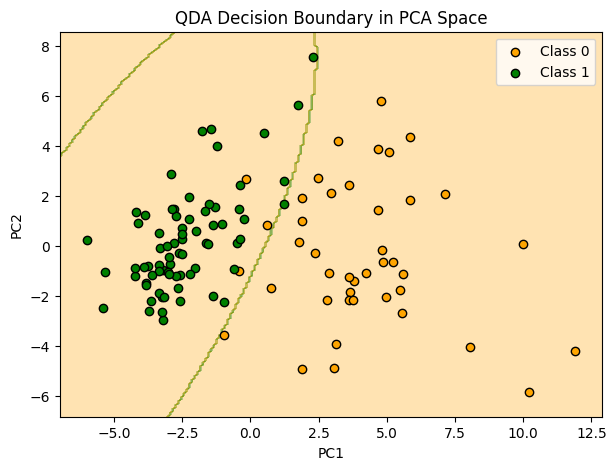

In [167]:
# decision overlay for QDA

# create mesh grid
x_min, x_max = x_val_pca[:, 0].min() - 1, x_val_pca[:, 0].max() + 1
y_min, y_max = x_val_pca[:, 1].min() - 1, x_val_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# predict for each point in the grid
qda = QuadraticDiscriminantAnalysis()
qda.fit(x_train_pca, y_train)
Z = qda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, colors=['orange','green'])

# plot validation points
plt.scatter(x_val_pca[y_val==0,0], x_val_pca[y_val==0,1], color='orange', label='Class 0', edgecolor='k')
plt.scatter(x_val_pca[y_val==1,0], x_val_pca[y_val==1,1], color='green', label='Class 1', edgecolor='k')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('QDA Decision Boundary in PCA Space')
plt.legend()
plt.show()
